# Residual MLForecast Experiments

This notebook uses the same MLForecast models as the original experiments, but with a different forecasting strategy:

**Residual Prediction**:
- For each rolling origin, take the last value of the historical window (y_last)
- Target: residual[h] = y_true[h] - y_last, h = 1..7
- Use MLForecast to predict the residual
- Final prediction: y_pred[h] = y_last + residual_pred[h]

This approach transforms the prediction task from forecasting absolute values to forecasting deviations from the last known value.

In [1]:
import importlib

import config as shared_config
import experiment
import experiment.config
import experiment.data
import experiment.rolling_forecast.artifacts
import experiment.rolling_forecast.executors
import experiment.rolling_forecast.executors.mlforecast
import experiment.rolling_forecast.executors.residual_mlforecast
import experiment.rolling_forecast.runner
import experiment.rolling_forecast.runtime
import experiment.rolling_forecast.types

importlib.reload(shared_config)
importlib.reload(experiment.config)
importlib.reload(experiment.data)
importlib.reload(experiment.rolling_forecast.artifacts)
importlib.reload(experiment.rolling_forecast.executors.residual_mlforecast)
importlib.reload(experiment.rolling_forecast.executors.mlforecast)
importlib.reload(experiment.rolling_forecast.executors)
importlib.reload(experiment.rolling_forecast.runtime)
importlib.reload(experiment.rolling_forecast.runner)
importlib.reload(experiment)

from experiment import DatasetBuilder, ModelSpec, RollingForecastRunner, RunConfig
from experiment.rolling_forecast.executors import ResidualMLForecastExecutor
from experiment.rolling_forecast.types import ExecutionContext
from experiment.rolling_forecast import artifacts as artifacts_module

In [2]:
# Load dataset
prepared_dataset = DatasetBuilder.from_csv(
    csv_path=shared_config.CSV_PATH,
    unique_id=shared_config.UNIQUE_ID,
    remove_last_month=shared_config.REMOVE_LAST_MONTH,
    hist_exog=shared_config.HIST_EXOG_LIST,
    futr_exog=shared_config.FUTR_EXOG_LIST,
)

In [3]:
def build_run_config(*, use_hist_exog: bool, use_futr_exog: bool) -> RunConfig:
    return RunConfig(
        input_size=shared_config.INPUT_SIZE,
        horizon=shared_config.HORIZON,
        split_ratio=shared_config.SPLIT_RATIO,
        sliding_step_size=shared_config.SLIDING_STEP_SIZE,
        use_hist_exog=use_hist_exog,
        use_futr_exog=use_futr_exog,
        save_plots=shared_config.SAVE_PLOTS,
        random_seed=shared_config.RANDOM_SEED,
        early_stop_patience_epochs=shared_config.EARLY_STOP_PATIENCE_EPOCHS,
        ml_early_stopping_rounds=shared_config.ML_EARLY_STOPPING_ROUNDS,
        neural_loss_name=shared_config.NEURAL_LOSS_NAME,
        neural_loss_params=shared_config.NEURAL_LOSS_PARAMS,
        neural_checkpoint_mode=shared_config.CHECKPOINT_MODE,
        save_dir=shared_config.SAVE_DIR,
        plot_forecast=shared_config.PLOT_FORECAST,
        plot_loss=shared_config.PLOT_LOSS,
        plot_loss_name=shared_config.PLOT_LOSS_NAME,
        freq=shared_config.FREQ,
    )


from mlforecast import MLForecast
from mlforecast.lag_transforms import ExpandingMean, RollingMean

USE_HIST_EXOG = False
USE_FUTR_EXOG_NO_EXOG = False
USE_FUTR_EXOG_WITH_KNOWN_FUTURE = True

MLFORECAST_LAGS = [1, 2, 3, 7, 14, 28]
MLFORECAST_LAG_TRANSFORMS = {
    1: [ExpandingMean()],
    7: [RollingMean(window_size=7), RollingMean(window_size=14)],
}
MLFORECAST_DATE_FEATURES = ["dayofweek", "month"]
COMMON_MLFORECAST_PARAMS = {
    "lags": MLFORECAST_LAGS,
    "lag_transforms": MLFORECAST_LAG_TRANSFORMS,
    "date_features": MLFORECAST_DATE_FEATURES,
    "num_threads": 1,
}

run_config_no_exog = build_run_config(
    use_hist_exog=USE_HIST_EXOG,
    use_futr_exog=USE_FUTR_EXOG_NO_EXOG,
)
run_config_futr_exog = build_run_config(
    use_hist_exog=USE_HIST_EXOG,
    use_futr_exog=USE_FUTR_EXOG_WITH_KNOWN_FUTURE,
)

runner_no_exog = RollingForecastRunner(
    prepared_dataset=prepared_dataset,
    run_config=run_config_no_exog,
)
runner_futr_exog = RollingForecastRunner(
    prepared_dataset=prepared_dataset,
    run_config=run_config_futr_exog,
)

In [4]:
from datetime import datetime
from pathlib import Path

def create_residual_executor_context(runner: RollingForecastRunner, model_spec: ModelSpec) -> ExecutionContext:
    """Create an ExecutionContext for the ResidualMLForecastExecutor."""
    # Use the same data splitting and artifact directory logic as RollingForecastRunner
    hist_exog = []  # ResidualMLForecastExecutor doesn't support hist exog
    futr_exog = runner._resolve_future_exog(model_spec) if hasattr(runner, '_resolve_future_exog') else []
    split_data = runner._split_dataset(prepared_dataset.df)
    
    feature_tag = runner._feature_tag(hist_exog=hist_exog, futr_exog=futr_exog)
    artifact_dir = runner._create_artifact_dir(
        model_name=f"Residual_{model_spec.name}",
        feature_tag=feature_tag,
    )
    
    return ExecutionContext(
        dataset=prepared_dataset,
        run_config=runner.run_config,
        model_spec=model_spec,
        hist_exog=hist_exog,
        futr_exog=futr_exog,
        future_cols=["unique_id", "ds"] + futr_exog,
        artifact_dir=artifact_dir,
        split_data=split_data,
    ), split_data  # Return both context and split_data


def run_residual_experiment(runner: RollingForecastRunner, model_spec: ModelSpec, run_name: str = None):
    """Run a residual experiment using ResidualMLForecastExecutor."""
    # Create context for residual executor
    context, split_data = create_residual_executor_context(runner, model_spec)
    
    # Set random seed
    experiment.rolling_forecast.runtime.set_random_seed(runner.run_config.random_seed)
    
    # Create and run residual executor
    executor = ResidualMLForecastExecutor(context=context)
    
    with experiment.rolling_forecast.runtime.suppress_lightning_logs():
        output = executor.run()
    
    # Use the same finalize_phase logic as RollingForecastRunner
    val_phase = artifacts_module.finalize_phase(
        context=context,
        phase_name="val",
        target_df=split_data.val,
        phase_output=output.val_phase,
    )
    test_phase = artifacts_module.finalize_phase(
        context=context,
        phase_name="test",
        target_df=split_data.test,
        phase_output=output.test_phase,
        checkpoint_label=output.test_checkpoint_label,
    )
    
    from experiment.config import ExperimentResult
    return ExperimentResult(
        model_name=f"Residual_{model_spec.name}",
        val_origin_mape_df=val_phase.origin_mape_df,
        val_overall_mape=val_phase.overall_mape,
        val_best_origin=val_phase.best_origin,
        val_worst_origin=val_phase.worst_origin,
        origin_mape_df=test_phase.origin_mape_df,
        overall_mape=test_phase.overall_mape,
        best_origin=test_phase.best_origin,
        worst_origin=test_phase.worst_origin,
        artifact_dir=str(context.artifact_dir),
        best_model_path=output.best_model_path,
        val_best_model_path=output.val_best_model_path,
        test_best_model_path=output.test_best_model_path,
        metrics_path=output.metrics_path,
        loss_plot_path=output.loss_plot_path,
        forecast_plot_path=test_phase.forecast_plot_path,
        rolling_raw_path=test_phase.rolling_raw_path,
        overlay_plot_path=test_phase.overlay_plot_path,
        skipped=False,
        skip_reason=None,
        used_exog=bool(context.hist_exog or context.futr_exog),
        requested_use_exog=runner.run_config.use_exog,
        val_diagnostics=val_phase.diagnostics,
        diagnostics=test_phase.diagnostics,
        train_size=split_data.n_train,
        val_size=split_data.n_val,
        test_size=split_data.n_test,
        val_n_origins=len(split_data.val_origins),
        n_origins=len(split_data.test_origins),
    )


def run_no_exog_and_futr_exog_residual(model_spec: ModelSpec):
    """Run residual experiment with both no_exog and futr_exog configurations."""
    no_exog_result = run_residual_experiment(runner_no_exog, model_spec)
    print("no_exog", no_exog_result.summary())
    print(f"no_exog rolling_raw_path: {no_exog_result.rolling_raw_path}")
    print()
    
    futr_exog_result = run_residual_experiment(runner_futr_exog, model_spec)
    print("futr_exog", futr_exog_result.summary())
    print(f"futr_exog rolling_raw_path: {futr_exog_result.rolling_raw_path}")
    
    return {"no_exog": no_exog_result, "futr_exog": futr_exog_result}

Seed set to 2026


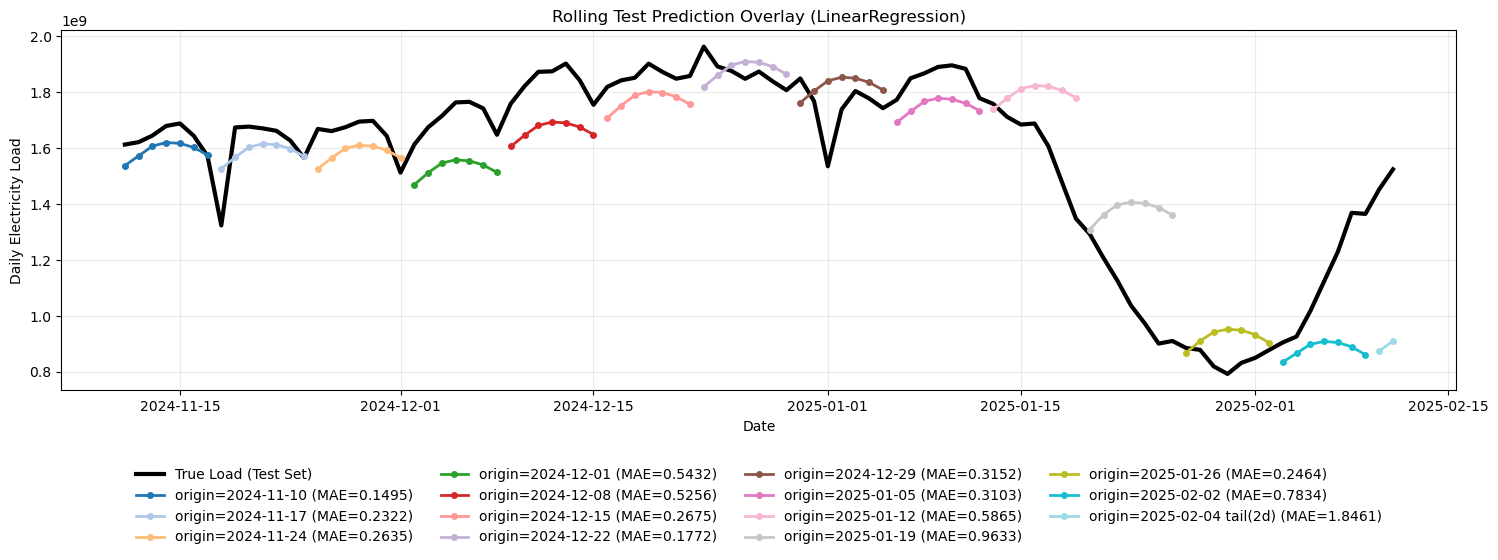

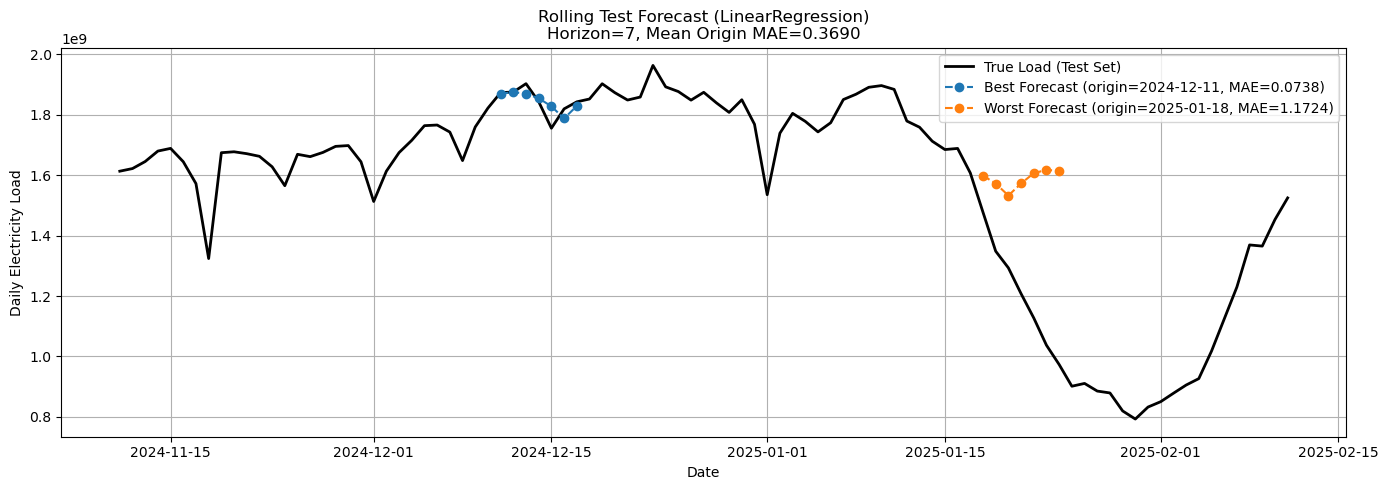

Seed set to 2026


no_exog {'model_name': 'Residual_LinearRegression', 'val_overall_mape': 4.477424420001122, 'overall_mape': 9.005364012872006, 'skipped': False, 'skip_reason': None, 'artifact_dir': 'artifacts\\Residual_LinearRegression_no_feat\\20260423_205926', 'best_model_path': None, 'val_best_model_path': None, 'test_best_model_path': None, 'rolling_raw_path': 'artifacts\\Residual_LinearRegression_no_feat\\20260423_205926\\rolling_test_raw.csv', 'overlay_plot_path': 'artifacts\\Residual_LinearRegression_no_feat\\20260423_205926\\rolling_test_overlay.png'}
no_exog rolling_raw_path: artifacts\Residual_LinearRegression_no_feat\20260423_205926\rolling_test_raw.csv



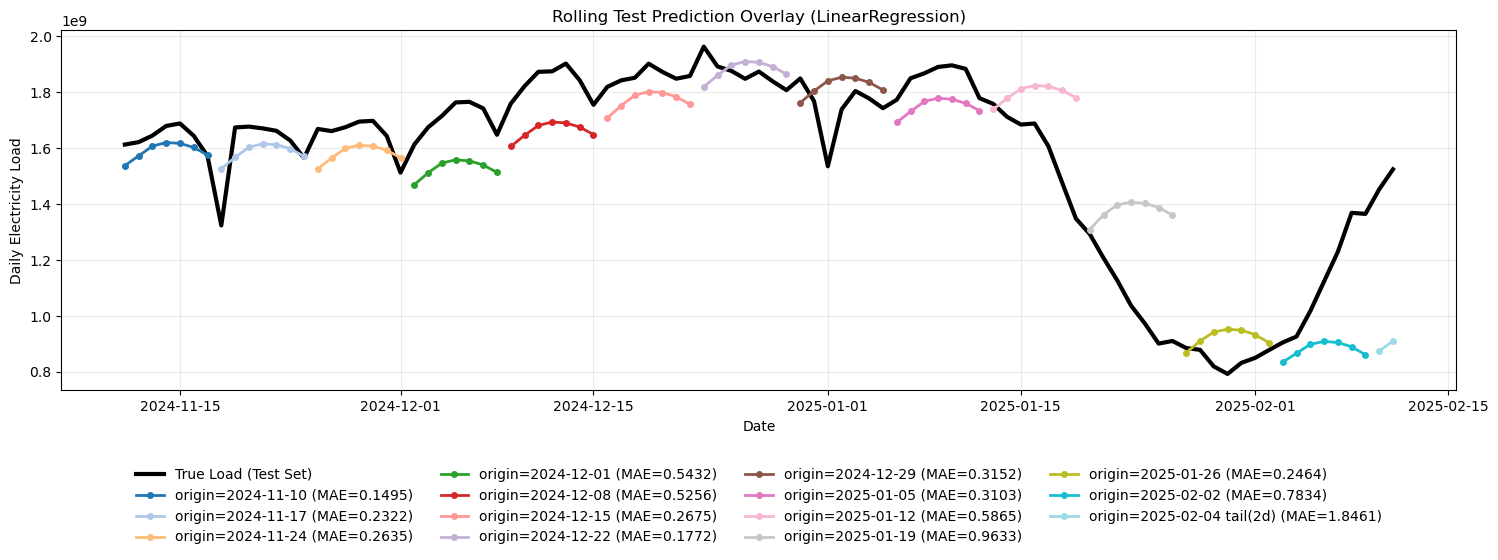

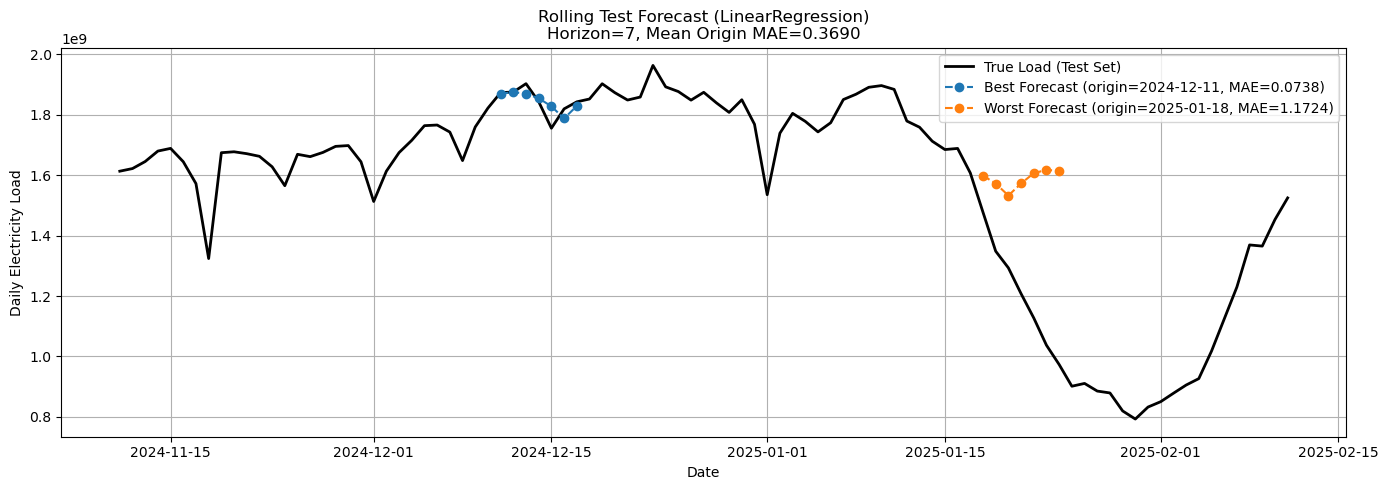

futr_exog {'model_name': 'Residual_LinearRegression', 'val_overall_mape': 4.477424420001122, 'overall_mape': 9.005364012872006, 'skipped': False, 'skip_reason': None, 'artifact_dir': 'artifacts\\Residual_LinearRegression_futr_feat\\20260423_205934', 'best_model_path': None, 'val_best_model_path': None, 'test_best_model_path': None, 'rolling_raw_path': 'artifacts\\Residual_LinearRegression_futr_feat\\20260423_205934\\rolling_test_raw.csv', 'overlay_plot_path': 'artifacts\\Residual_LinearRegression_futr_feat\\20260423_205934\\rolling_test_overlay.png'}
futr_exog rolling_raw_path: artifacts\Residual_LinearRegression_futr_feat\20260423_205934\rolling_test_raw.csv


In [5]:
from sklearn.linear_model import LinearRegression

linear_regression_spec = ModelSpec(
    name="LinearRegression",
    model_type="mlforecast",
    model_cls=MLForecast,
    model_params={
        **COMMON_MLFORECAST_PARAMS,
        "models": LinearRegression(),
    },
    supports_hist_exog=False,
    supports_future_exog=True,
)

linear_regression_results = run_no_exog_and_futr_exog_residual(linear_regression_spec)

Seed set to 2026
d:\miniconda\envs\dl\Lib\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=8.09986e-17): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


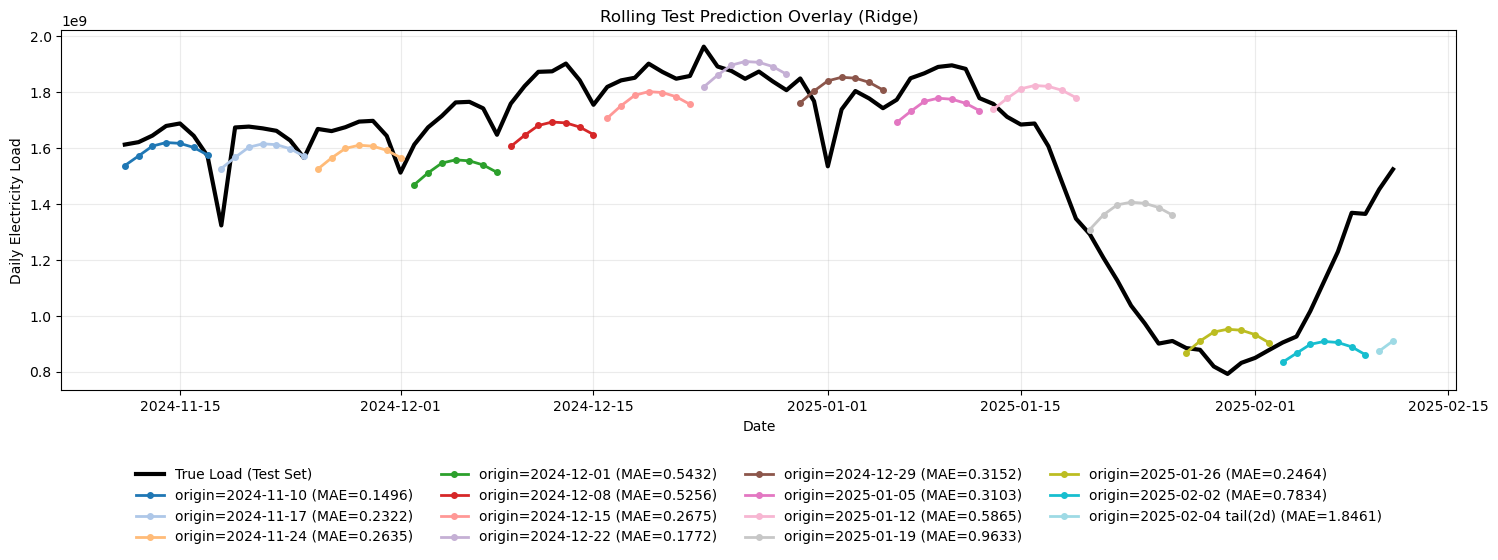

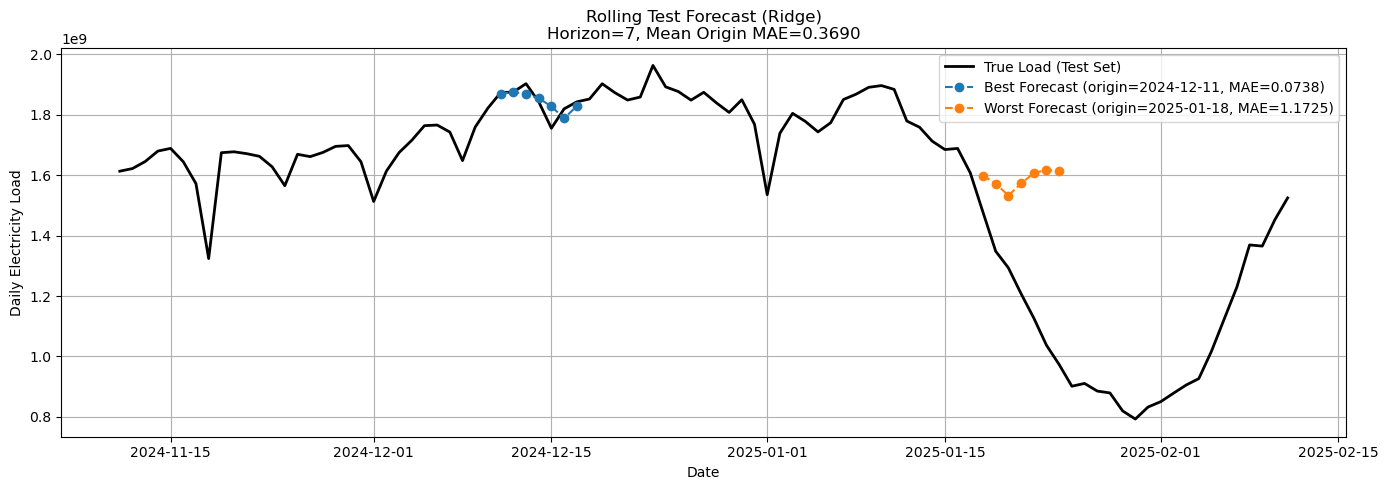

Seed set to 2026


no_exog {'model_name': 'Residual_Ridge', 'val_overall_mape': 4.39959918667562, 'overall_mape': 9.00525004063777, 'skipped': False, 'skip_reason': None, 'artifact_dir': 'artifacts\\Residual_Ridge_no_feat\\20260423_205942', 'best_model_path': None, 'val_best_model_path': None, 'test_best_model_path': None, 'rolling_raw_path': 'artifacts\\Residual_Ridge_no_feat\\20260423_205942\\rolling_test_raw.csv', 'overlay_plot_path': 'artifacts\\Residual_Ridge_no_feat\\20260423_205942\\rolling_test_overlay.png'}
no_exog rolling_raw_path: artifacts\Residual_Ridge_no_feat\20260423_205942\rolling_test_raw.csv



d:\miniconda\envs\dl\Lib\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=8.09986e-17): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


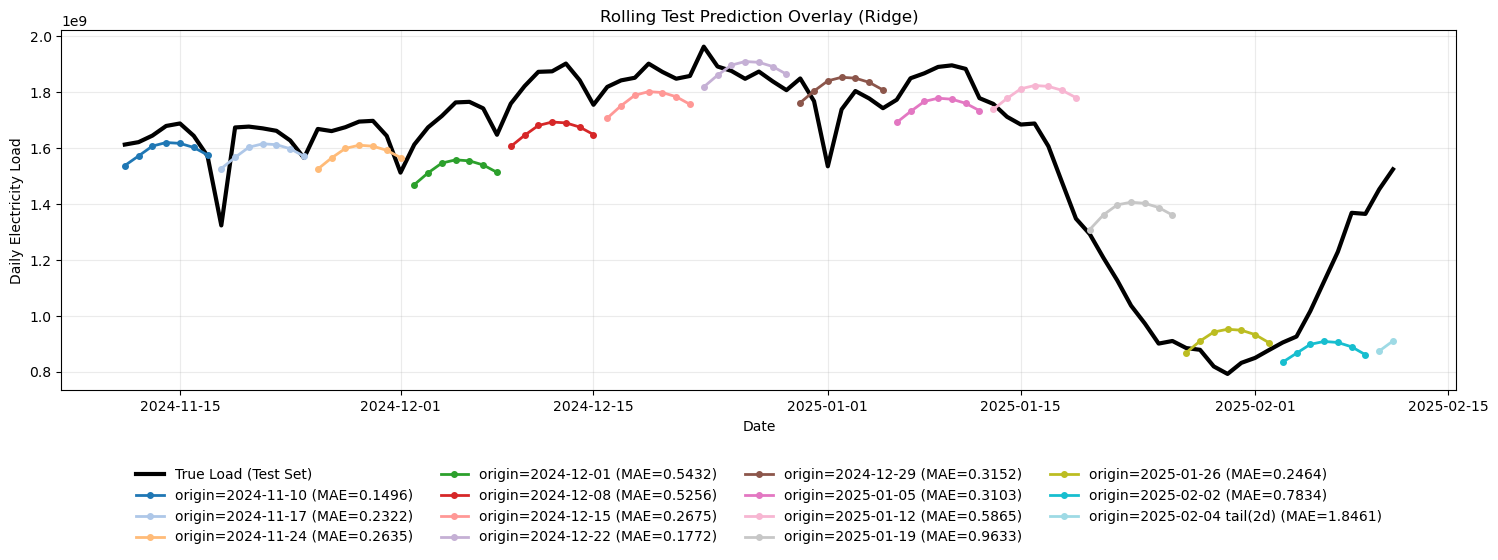

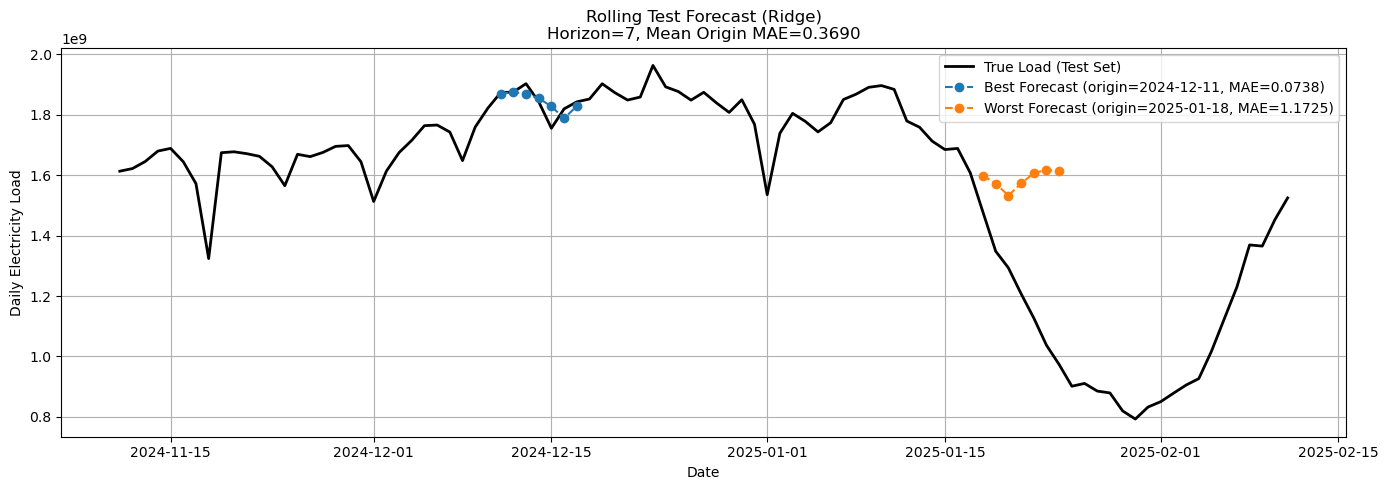

futr_exog {'model_name': 'Residual_Ridge', 'val_overall_mape': 4.39959918667562, 'overall_mape': 9.00525004063777, 'skipped': False, 'skip_reason': None, 'artifact_dir': 'artifacts\\Residual_Ridge_futr_feat\\20260423_205949', 'best_model_path': None, 'val_best_model_path': None, 'test_best_model_path': None, 'rolling_raw_path': 'artifacts\\Residual_Ridge_futr_feat\\20260423_205949\\rolling_test_raw.csv', 'overlay_plot_path': 'artifacts\\Residual_Ridge_futr_feat\\20260423_205949\\rolling_test_overlay.png'}
futr_exog rolling_raw_path: artifacts\Residual_Ridge_futr_feat\20260423_205949\rolling_test_raw.csv


In [6]:
from sklearn.linear_model import Ridge

ridge_spec = ModelSpec(
    name="Ridge",
    model_type="mlforecast",
    model_cls=MLForecast,
    model_params={
        **COMMON_MLFORECAST_PARAMS,
        "models": Ridge(alpha=1.0, random_state=shared_config.RANDOM_SEED),
    },
    supports_hist_exog=False,
    supports_future_exog=True,
)

ridge_results = run_no_exog_and_futr_exog_residual(ridge_spec)

Seed set to 2026


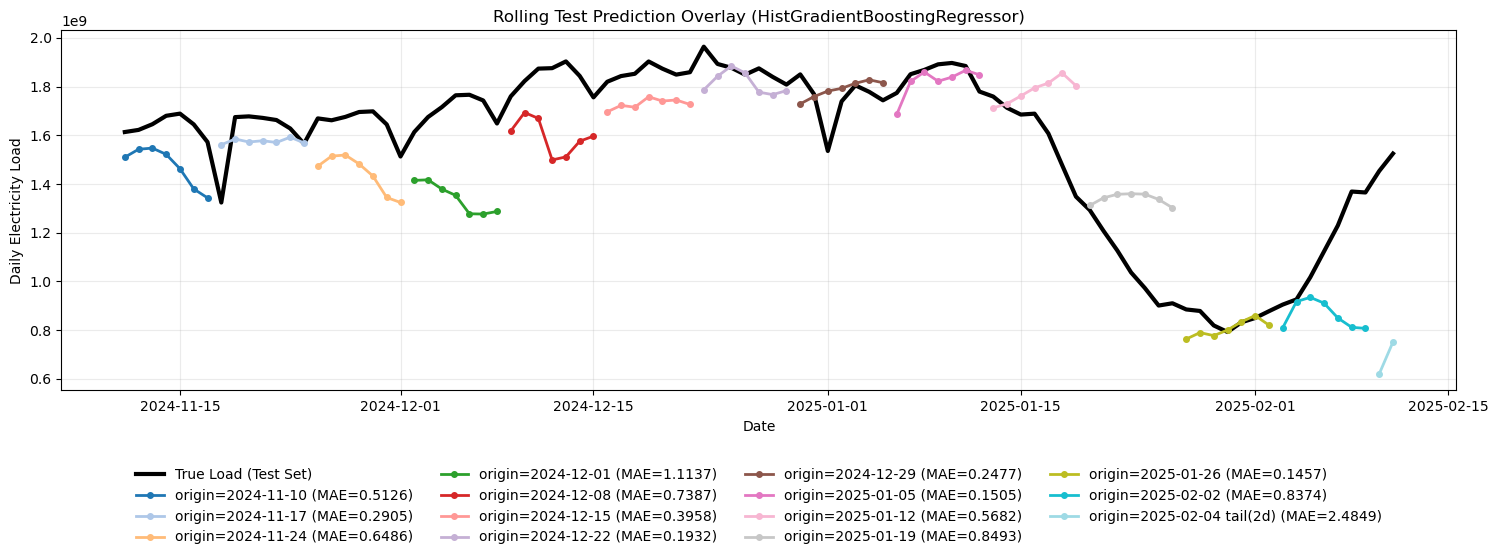

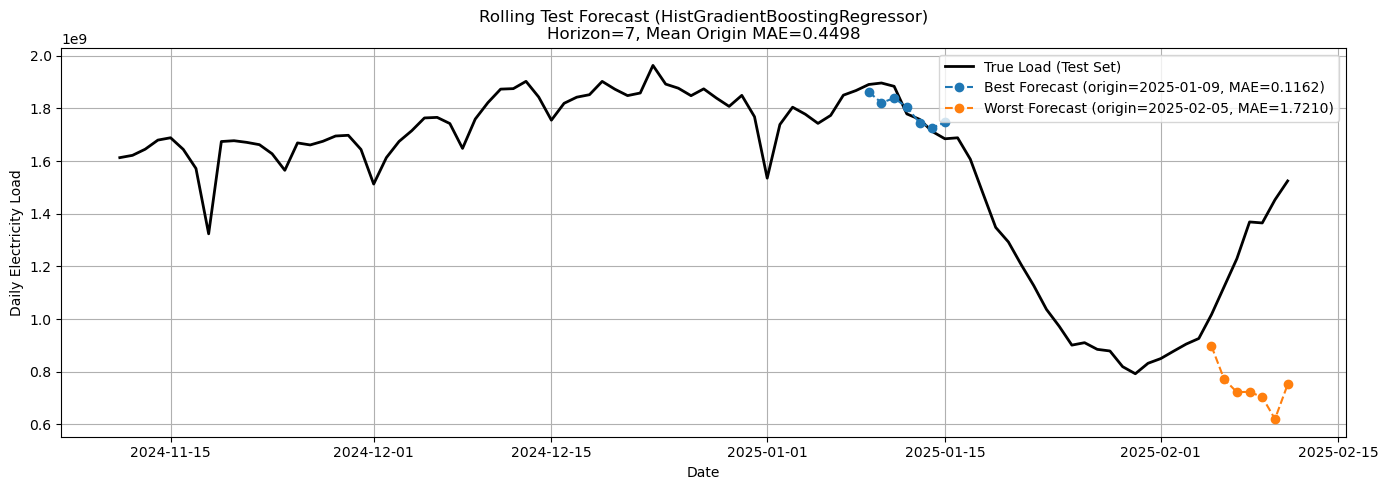

Seed set to 2026


no_exog {'model_name': 'Residual_HistGradientBoostingRegressor', 'val_overall_mape': 4.414650616469181, 'overall_mape': 10.59785374762645, 'skipped': False, 'skip_reason': None, 'artifact_dir': 'artifacts\\Residual_HistGradientBoostingRegressor_no_feat\\20260423_205957', 'best_model_path': None, 'val_best_model_path': None, 'test_best_model_path': None, 'rolling_raw_path': 'artifacts\\Residual_HistGradientBoostingRegressor_no_feat\\20260423_205957\\rolling_test_raw.csv', 'overlay_plot_path': 'artifacts\\Residual_HistGradientBoostingRegressor_no_feat\\20260423_205957\\rolling_test_overlay.png'}
no_exog rolling_raw_path: artifacts\Residual_HistGradientBoostingRegressor_no_feat\20260423_205957\rolling_test_raw.csv



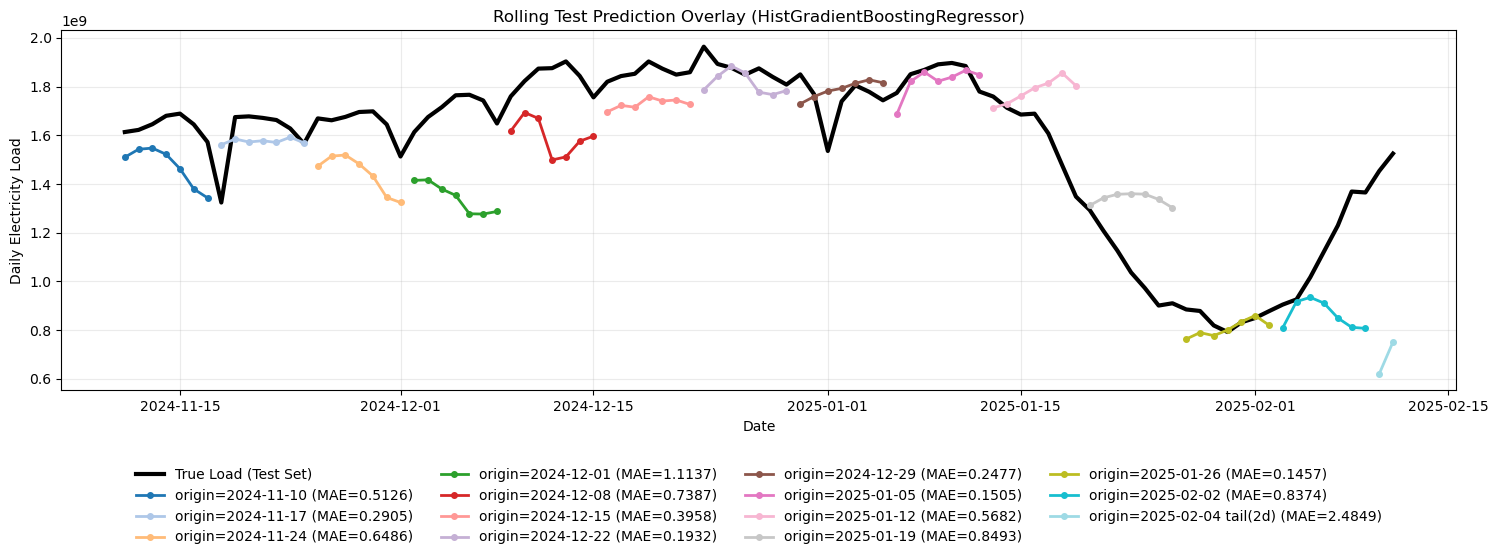

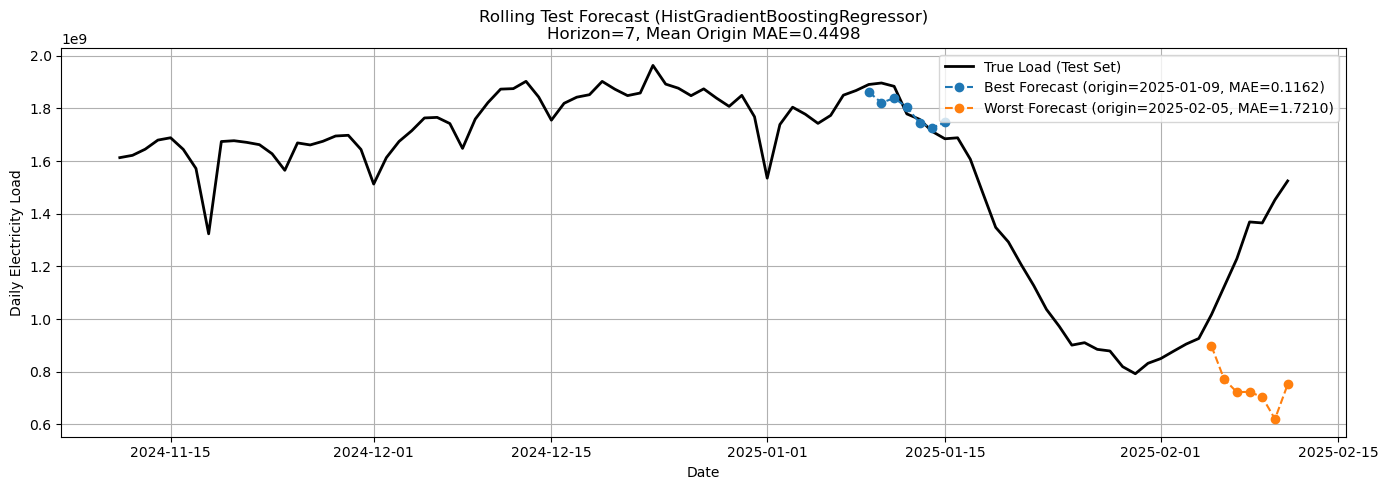

futr_exog {'model_name': 'Residual_HistGradientBoostingRegressor', 'val_overall_mape': 4.414650616469181, 'overall_mape': 10.59785374762645, 'skipped': False, 'skip_reason': None, 'artifact_dir': 'artifacts\\Residual_HistGradientBoostingRegressor_futr_feat\\20260423_210100', 'best_model_path': None, 'val_best_model_path': None, 'test_best_model_path': None, 'rolling_raw_path': 'artifacts\\Residual_HistGradientBoostingRegressor_futr_feat\\20260423_210100\\rolling_test_raw.csv', 'overlay_plot_path': 'artifacts\\Residual_HistGradientBoostingRegressor_futr_feat\\20260423_210100\\rolling_test_overlay.png'}
futr_exog rolling_raw_path: artifacts\Residual_HistGradientBoostingRegressor_futr_feat\20260423_210100\rolling_test_raw.csv


In [7]:
from sklearn.ensemble import HistGradientBoostingRegressor

hist_gradient_boosting_spec = ModelSpec(
    name="HistGradientBoostingRegressor",
    model_type="mlforecast",
    model_cls=MLForecast,
    model_params={
        **COMMON_MLFORECAST_PARAMS,
        "models": HistGradientBoostingRegressor(
            max_iter=300,
            learning_rate=0.05,
            random_state=shared_config.RANDOM_SEED,
        ),
    },
    supports_hist_exog=False,
    supports_future_exog=True,
)

hist_gradient_boosting_results = run_no_exog_and_futr_exog_residual(hist_gradient_boosting_spec)

Seed set to 2026


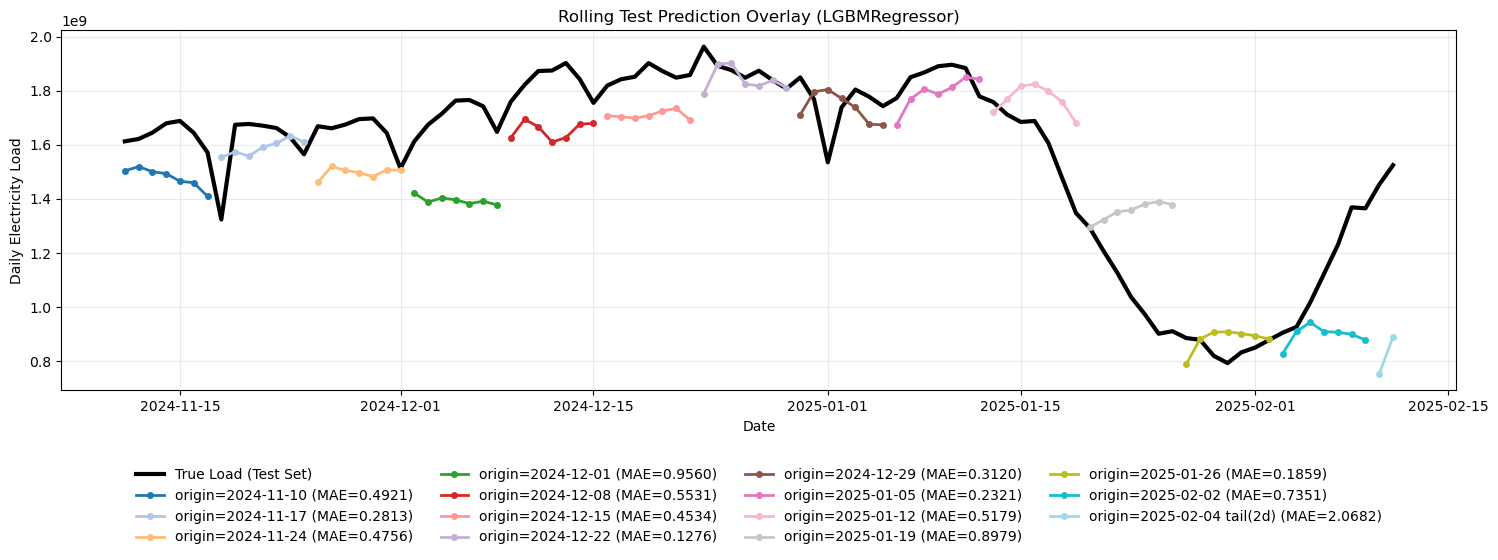

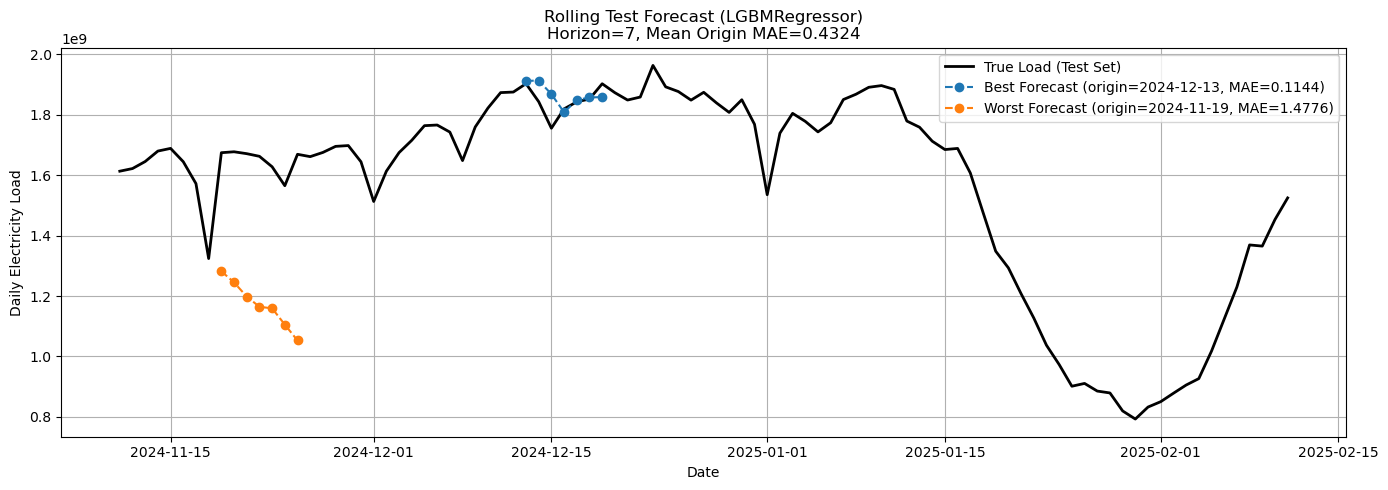

Seed set to 2026


no_exog {'model_name': 'Residual_LGBMRegressor', 'val_overall_mape': 4.380614097871209, 'overall_mape': 10.304836452632959, 'skipped': False, 'skip_reason': None, 'artifact_dir': 'artifacts\\Residual_LGBMRegressor_no_feat\\20260423_210212', 'best_model_path': None, 'val_best_model_path': None, 'test_best_model_path': None, 'rolling_raw_path': 'artifacts\\Residual_LGBMRegressor_no_feat\\20260423_210212\\rolling_test_raw.csv', 'overlay_plot_path': 'artifacts\\Residual_LGBMRegressor_no_feat\\20260423_210212\\rolling_test_overlay.png'}
no_exog rolling_raw_path: artifacts\Residual_LGBMRegressor_no_feat\20260423_210212\rolling_test_raw.csv



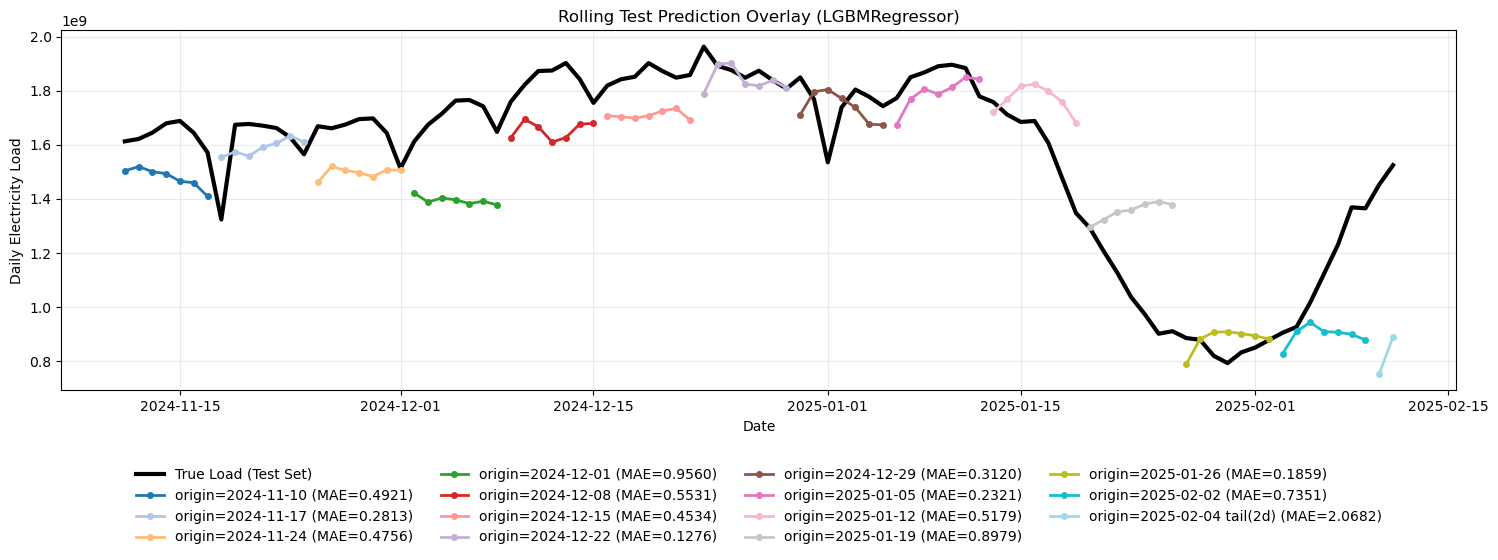

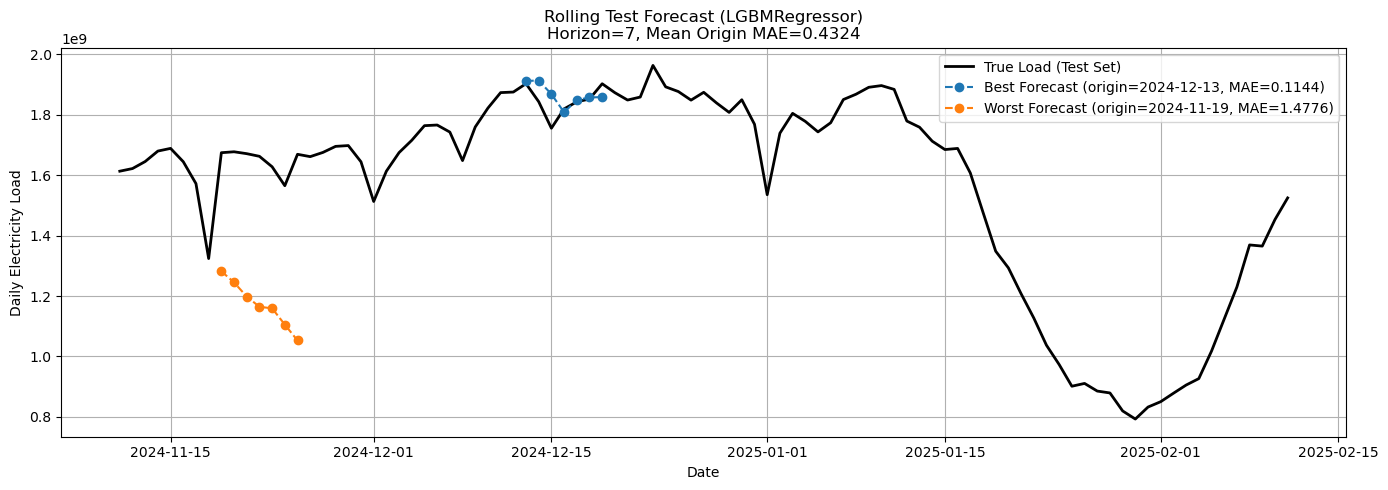

futr_exog {'model_name': 'Residual_LGBMRegressor', 'val_overall_mape': 4.380614097871209, 'overall_mape': 10.304836452632959, 'skipped': False, 'skip_reason': None, 'artifact_dir': 'artifacts\\Residual_LGBMRegressor_futr_feat\\20260423_210230', 'best_model_path': None, 'val_best_model_path': None, 'test_best_model_path': None, 'rolling_raw_path': 'artifacts\\Residual_LGBMRegressor_futr_feat\\20260423_210230\\rolling_test_raw.csv', 'overlay_plot_path': 'artifacts\\Residual_LGBMRegressor_futr_feat\\20260423_210230\\rolling_test_overlay.png'}
futr_exog rolling_raw_path: artifacts\Residual_LGBMRegressor_futr_feat\20260423_210230\rolling_test_raw.csv


In [8]:
from lightgbm import LGBMRegressor

lgbm_spec = ModelSpec(
    name="LGBMRegressor",
    model_type="mlforecast",
    model_cls=MLForecast,
    model_params={
        **COMMON_MLFORECAST_PARAMS,
        "models": LGBMRegressor(
            n_estimators=300,
            learning_rate=0.05,
            num_leaves=15,
            random_state=shared_config.RANDOM_SEED,
            verbosity=-1,
        ),
    },
    supports_hist_exog=False,
    supports_future_exog=True,
)

lgbm_results = run_no_exog_and_futr_exog_residual(lgbm_spec)